In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
file="train.csv"
data=pd.read_csv(file)
df=pd.DataFrame(data)


C:\Users\shiva\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
per=df.isnull().sum()/(df.shape[0])*100
per
for i,col in per.items():
    if col>50:
        print(i)
        df=df.drop(columns={i})
df.isnull().sum()
df.columns

Cabin


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [3]:
df=df[["Name"]+[col for col in df.columns if col!="Name"]]

In [4]:
df=df.drop(columns=["Name"])

In [5]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,female,35.0,1,0,113803,53.1000,S
4,5,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,S
887,888,1,1,female,19.0,0,0,112053,30.0000,S
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,male,26.0,0,0,111369,30.0000,C


In [6]:
colns=[col for col in df.columns if col!="Survived"]+["Survived"]

In [7]:
df=df[colns]

In [8]:
df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,3,male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,female,38.0,1,0,PC 17599,71.2833,C,1
2,3,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,female,35.0,1,0,113803,53.1000,S,1
4,5,3,male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,2,male,27.0,0,0,211536,13.0000,S,0
887,888,1,female,19.0,0,0,112053,30.0000,S,1
888,889,3,female,NaN,1,2,W./C. 6607,23.4500,S,0
889,890,1,male,26.0,0,0,111369,30.0000,C,1


In [9]:
model=LabelEncoder()

In [10]:
df["Sex"]=model.fit_transform(df["Sex"])

In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
model=IterativeImputer()

In [12]:
import pandas as pd

imputer = IterativeImputer()

df["Age"] = imputer.fit_transform(df[["Age"]])
df["Age"]=df["Age"].astype(int)
df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,3,1,22,1,0,A/5 21171,7.2500,S,0
1,2,1,0,38,1,0,PC 17599,71.2833,C,1
2,3,3,0,26,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,0,35,1,0,113803,53.1000,S,1
4,5,3,1,35,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,2,1,27,0,0,211536,13.0000,S,0
887,888,1,0,19,0,0,112053,30.0000,S,1
888,889,3,0,29,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,26,0,0,111369,30.0000,C,1


In [31]:
import numpy as np

df["Age"] = [i if 2 < i < 88 else np.nan for i in df["Age"]]
df["Age"].isnull().sum()

171

In [34]:
df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,3,1,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,0,38.0,1,0,PC 17599,71.2833,C,1
2,3,3,0,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,0,35.0,1,0,113803,53.1000,S,1
4,5,3,1,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,2,1,27.0,0,0,211536,13.0000,S,0
887,888,1,0,19.0,0,0,112053,30.0000,S,1
888,889,3,0,29.0,1,2,W./C. 6607,23.4500,S,0
889,890,1,1,26.0,0,0,111369,30.0000,C,1


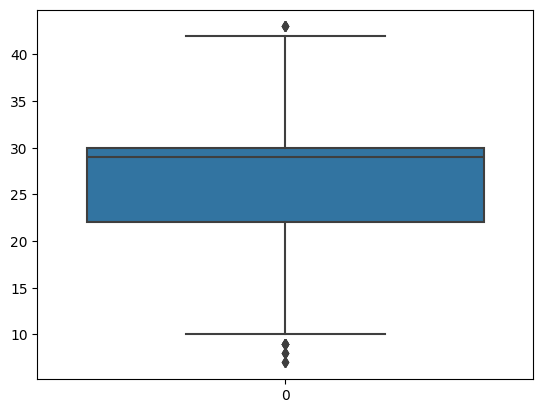

In [33]:
import seaborn as sns
sns.boxplot(df["Age"])
plt.show()